In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import *
from MODELS.teamInfo import *


In [20]:
q10_model = joblib.load('../MODELS/SAVED_MODELS/xgb_q10_modelv2.pkl')
q50_model = joblib.load('../MODELS/SAVED_MODELS/xgb_q50_modelv2.pkl')
q90_model = joblib.load('../MODELS/SAVED_MODELS/xgb_q90_modelv2.pkl')
models = {'q10': q10_model, 'q50': q50_model, 'q90': q90_model}
features = joblib.load('../MODELS/SAVED_MODELS/feature_list.pkl')

In [21]:
pd.set_option('display.max_columns', None)

s25_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s24_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')

df = pd.concat([s25_pts, s24_pts]).sort_values(by='GAME_DATE')

date = '2024-11-30'

In [23]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'prizepicks') &  (backtestData['CATEGORY'] == 'player_points')]
backtestData.sample(5)


/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_88639/2718787215.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
188690,188690,188690,107985,T. Vukcevic,player_points,prizepicks,under,14.0,-137,Washington Wizards,Philadelphia 76ers,NaN,NaN,2025-04-09,game,13.5,100.0,under
53316,53316,53316,53316,Taurean Prince,player_points,prizepicks,under,7.0,-137,San Antonio Spurs,Milwaukee Bucks,NaN,NaN,2025-02-01,game,6.5,101.0,under
36080,36080,36080,36080,Donovan Mitchell,player_points,prizepicks,under,23.0,-137,Golden State Warriors,Cleveland Cavaliers,1acd3d3cfc7eecfb83fbb98946dde600,2024-12-31T03:10:00Z,2024-12-30,NaN,NaN,NaN,under
38351,38351,38351,38351,Trae Young,player_points,prizepicks,under,23.5,-137,Los Angeles Lakers,Atlanta Hawks,59819cf3348408e741b42cb5c0536e78,2025-01-04T03:40:00Z,2025-01-03,NaN,NaN,NaN,under
24990,24990,24990,24990,Shaedon Sharpe,player_points,prizepicks,over,15.5,-137,Los Angeles Lakers,Portland Trail Blazers,0717c42f68b5c2524c27431cf8861329,2024-12-09T02:40:00Z,2024-12-08,NaN,NaN,NaN,over


In [24]:
results = backtestPairs(
    data=df,
    backtestData=backtestData,
    gameDate='2024-12-27',
    models=models,  
    features=features,
    edge_threshold=0.20, 
    top_n=10, 
    variance_inflation=1.1, 
    distribution_type='skew_t', stat_col='PTS', 
    use_monte_carlo=False, n_simulations=10000, max_kelly=0.25, stake=100)

# Comprehensive results analysis
if not results.empty:
    print("=" * 60)
    print("PAIR BETTING RESULTS ANALYSIS")
    print("=" * 60)
    
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Calculate profit/loss
    total_profit = results['pair_profit'].sum()
    avg_profit = results['pair_profit'].mean()
    
    print(f"Total Bets: {total_bets}")
    print(f"Wins: {total_wins}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total Profit: ${total_profit:.2f}")
    print(f"Average Profit per Bet: ${avg_profit:.2f}")

results

PAIR BETTING RESULTS ANALYSIS
Total Bets: 10
Wins: 4
Win Rate: 40.00%
Total Profit: $200.00
Average Profit per Bet: $20.00


,player1,player2,model_side1,model_side2,line1,line2,pred1,pred2,q10_1,q90_1,q10_2,q90_2,actual1,actual2,edge1,edge2,leg1_won,leg2_won,pair_won,pair_recommendation,pair_profit,ev_percent,kelly_full,kelly_capped,kelly_bet_size,kelly_bet_size_full,stake,prob_both,combined_edge,simulation_method,date
0,Jalen Suggs,Bradley Beal,under,under,20.5,21.5,13.37,14.32,5.84,23.70,6.66,23.79,27,11,0.246,0.257,0,1,0,1,-100.0,1.06,0.532,0.25,25.0,53.19,100,0.6879,0.251,Analytical,2024-12-27
1,Bradley Beal,Kyrie Irving,under,under,21.5,26.5,14.32,18.84,6.66,23.79,9.52,29.29,11,20,0.257,0.238,1,1,1,1,200.0,1.05,0.523,0.25,25.0,52.27,100,0.6818,0.248,Analytical,2024-12-27
2,Jalen Suggs,Kyrie Irving,under,under,20.5,26.5,13.37,18.84,5.84,23.70,9.52,29.29,27,20,0.246,0.238,0,1,0,1,-100.0,1.02,0.509,0.25,25.0,50.87,100,0.6725,0.242,Analytical,2024-12-27
3,Tristan da Silva,Bradley Beal,under,under,13.0,21.5,8.17,14.32,2.23,17.05,6.66,23.79,0,11,0.198,0.257,1,1,1,0,200.0,0.94,0.472,0.25,25.0,47.22,100,0.6482,0.228,Analytical,2024-12-27
4,Tristan da Silva,Kyrie Irving,under,under,13.0,26.5,8.17,18.84,2.23,17.05,9.52,29.29,0,20,0.198,0.238,1,1,1,0,200.0,0.90,0.450,0.25,25.0,45.04,100,0.6336,0.218,Analytical,2024-12-27
5,Jalen Suggs,Kevin Durant,under,under,20.5,29.0,13.37,24.13,5.84,23.70,13.92,34.97,27,35,0.246,0.127,0,0,0,0,-100.0,0.74,0.371,0.25,25.0,37.09,100,0.5806,0.186,Analytical,2024-12-27
6,Kevin Durant,Kyrie Irving,under,under,29.0,26.5,24.13,18.84,13.92,34.97,9.52,29.29,35,20,0.127,0.238,0,1,0,0,-100.0,0.73,0.363,0.25,25.0,36.32,100,0.5755,0.183,Analytical,2024-12-27
7,Bradley Beal,Klay Thompson,under,under,21.5,16.5,14.32,12.62,6.66,23.79,3.97,23.04,11,11,0.257,0.104,1,1,1,0,200.0,0.71,0.355,0.25,25.0,35.47,100,0.5698,0.181,Analytical,2024-12-27
8,Jalen Suggs,Klay Thompson,under,under,20.5,16.5,13.37,12.62,5.84,23.70,3.97,23.04,27,11,0.246,0.104,0,1,0,0,-100.0,0.69,0.343,0.25,25.0,34.30,100,0.5620,0.175,Analytical,2024-12-27
9,Jaylen Wells,Bradley Beal,over,under,10.5,21.5,13.99,14.32,4.86,23.12,6.66,23.79,10,11,0.094,0.257,0,1,0,0,-100.0,0.68,0.342,0.25,25.0,34.17,100,0.5611,0.175,Analytical,2024-12-27


## Points

In [ ]:
uniqueDates = sorted(s25_pts['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPairs(
        data=df,
        backtestData=backtestData,
        gameDate=date,
        models=models,  
        features=features,
        edge_threshold=0.12, 
        top_n=10, 
        variance_inflation=1.1, 
        distribution_type='skew_t', stat_col='PTS', 
        use_monte_carlo=False, n_simulations=10000, max_kelly=0.25, stake=100)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-23... 1/162
  ✓ Processed 10 bets
Processing 2024-10-24... 2/162
  ✓ Processed 10 bets
Processing 2024-10-25... 3/162
  ✓ Processed 10 bets
Processing 2024-10-26... 4/162
  ✓ Processed 10 bets
Processing 2024-10-27... 5/162
  ✓ Processed 10 bets
Processing 2024-10-28... 6/162
  ✓ Processed 10 bets
Processing 2024-10-29... 7/162
  ✓ Processed 10 bets
Processing 2024-10-30... 8/162
  ✓ Processed 10 bets
Processing 2024-10-31... 9/162
  ✓ Processed 10 bets
Processing 2024-11-01... 10/162
  ✓ Processed 10 bets
Processing 2024-11-02... 11/162
  ✓ Processed 10 bets
Processing 2024-11-03... 12/162
  ✓ Processed 10 bets
Processing 2024-11-04... 13/162
  ✓ Processed 10 bets
Processing 2024-11-06... 14/162
  ✓ Processed 10 bets
Processing 2024-11-07... 15/162
  ✓ Processed 10 bets
Processing 2024-11-08... 16/162
  ✓ Processed 10 bets
Processing 2024-11-09... 17/162
  ✓ Processed 10 bets
Processing 2024-11-10... 18/162
  ✓ Processed 10 bets
Processing 2024-11-11... 19/162
  ✓ P

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,348
   Wins: 471
   Hit Rate: 34.94%
   Total Profit: $325.00
   Total Staked: $6,740.00
   ROI: 4.82%
   Volatility: $40.07
   Max Drawdown: $-540.00
   Sharpe Ratio: 0.698

 RECOMMENDED BETS ANALYSIS (Edge > 0.20):
   Total Bets: 89
   Wins: 41
   Hit Rate: 46.07%
   Total Profit: $170.00
   Total Staked: $445.00
   ROI: 38.20%
   Volatility: $24.75
   Max Drawdown: $-30.00
   Sharpe Ratio: 1.576


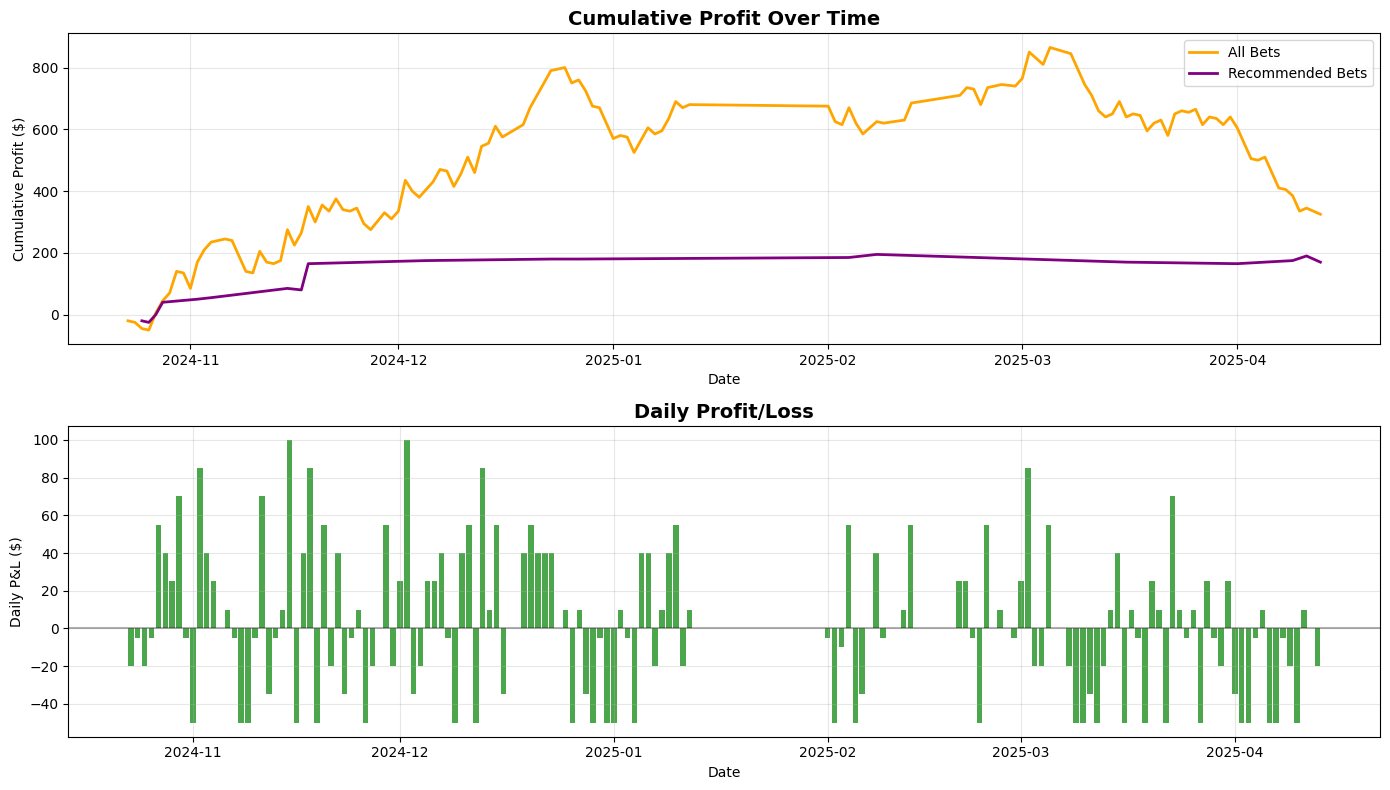

In [28]:
all_metrics = calculatePairMetrics(final_results, stake=5)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print("\n RECOMMENDED BETS ANALYSIS (Edge > 0.20):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [31]:
print(final_results['ev_percent'].max())
print(final_results['ev_percent'].min())
print(final_results['ev_percent'].mean())
print(final_results['ev_percent'].median())
print(final_results['ev_percent'].std())
print(final_results['ev_percent'].var())
print(final_results['ev_percent'].describe())


1.72
-0.22
0.5729302670623145
0.54
0.27896101305394994
0.07781924680408601
count    1348.000000
mean        0.572930
std         0.278961
min        -0.220000
25%         0.397500
50%         0.540000
75%         0.710000
max         1.720000
Name: ev_percent, dtype: float64


In [32]:
print(final_results['combined_edge'].max())
print(final_results['combined_edge'].min())
print(final_results['combined_edge'].mean())
print(final_results['combined_edge'].median())
print(final_results['combined_edge'].std())
print(final_results['combined_edge'].var())
print(final_results['combined_edge'].describe())

0.375
-0.069
0.1457114243323442
0.14
0.06308629237105645
0.003979880285126415
count    1348.000000
mean        0.145711
std         0.063086
min        -0.069000
25%         0.107000
50%         0.140000
75%         0.179000
max         0.375000
Name: combined_edge, dtype: float64


In [33]:
print(final_results['prob_both'].max())
print(final_results['prob_both'].min())
print(final_results['prob_both'].mean())
print(final_results['prob_both'].median())
print(final_results['prob_both'].std())
print(final_results['prob_both'].var())
print(final_results['prob_both'].describe())

0.908
0.2595
0.5242448071216618
0.5121
0.09301904991907281
0.008652543647846959
count    1348.000000
mean        0.524245
std         0.093019
min         0.259500
25%         0.465050
50%         0.512100
75%         0.568600
max         0.908000
Name: prob_both, dtype: float64


In [34]:
print(final_results['kelly_full'].max())
print(final_results['kelly_full'].min())
print(final_results['kelly_full'].mean())
print(final_results['kelly_full'].median())
print(final_results['kelly_full'].std())
print(final_results['kelly_full'].var())
print(final_results['kelly_full'].describe())

0.862
0.0
0.2869087537091988
0.268
0.1382664379090103
0.019117607852046203
count    1348.000000
mean        0.286909
std         0.138266
min         0.000000
25%         0.197750
50%         0.268000
75%         0.353000
max         0.862000
Name: kelly_full, dtype: float64
